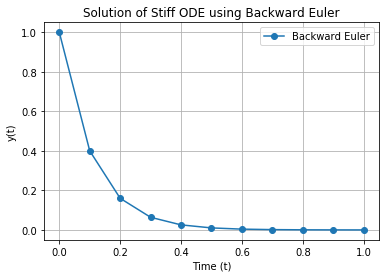

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
# Define the ODE
def f(t, y):
    return -15 * y
# Backward Euler method
def backward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]        
        # Implicit function to solve for y_next
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        # Use previous value as initial guess
        y_values[i] = fsolve(g, y_prev)      
    return t_values, y_values

# Parameters
y0 = 1
t0 = 0
tf = 1
h = 0.1
# Solve the ODE
t_values, y_values = backward_euler(f, y0, t0, tf, h)
# Plot the results
plt.plot(t_values, y_values, 'o-', label='Backward Euler')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

Newton Raphson:

In [3]:
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    x = x0


    for i in range(max_iter):
        x_new = x - g(x) / dg(x)

        if abs(x_new - x) < tol:
            return x_new, i + 1
        x = x_new
        print(x)
    return None, max_iter

# Example: Solving x^2 - 2 = 0
g = lambda x: x**2 - 2
dg = lambda x: 2*x
root, iterations = newton_raphson(g, dg, x0=1)
print(f"Root: {root}, Iterations: {iterations}")

1.5
1.4166666666666667
1.4142156862745099
1.4142135623746899
Root: 1.4142135623730951, Iterations: 5
